In [1]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
from src.visualisation.utils_colormap import CMAP
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

cmap_ir = CMAP.cira_ir()
cmap_sar = CMAP.cmap_sar()

def plot_sar(tensor, fig=None, ax=None, cmap=cmap_sar, title=None,
             x_lim=300, x=None, y=None):

    if ax is None:
        ax = plt.gca()

    if x is None:
        y_sar = np.linspace(-x_lim, x_lim, tensor.shape[0])
        x_sar = np.linspace(-x_lim, x_lim, tensor.shape[1])
        x_sar, y_sar = np.meshgrid(x_sar, y_sar)
    else:
        x_sar, y_sar = x, y   # déjà 2D, pas de meshgrid

    im = ax.pcolormesh(
        x_sar,
        y_sar,
        tensor,
        cmap=cmap,
        vmin=0,
        vmax=160/1.94384449,
        shading="auto"
    )

    if x is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)

    if title is not None:
        ax.set_title(title)

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

    ax.set_aspect("equal")


def plot_ir(tensor, fig=None, x=None, y=None, ax=None, x_lim=300,
            cmap=cmap_ir, vmin=-100, vmax=50):

    if ax is None:
        ax = plt.gca()

    tensor = np.squeeze(tensor)
    ny, nx = tensor.shape  # ny = rows, nx = cols

    if x is None:
        x = np.linspace(-x_lim, x_lim, nx)

    if y is None:
        y = np.linspace(-x_lim, x_lim, ny)

    im = ax.pcolormesh(
        x, y, tensor,
        cmap=cmap,
        shading="nearest",
        vmin=vmin,
        vmax=vmax
    )

    if x is None or y is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)
    else:
        ax.set_xlim(np.min(x), np.max(x))
        ax.set_ylim(np.min(y), np.max(y))
    ax.set_aspect("equal")

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")


In [1]:
csv_anggrek_path = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv"

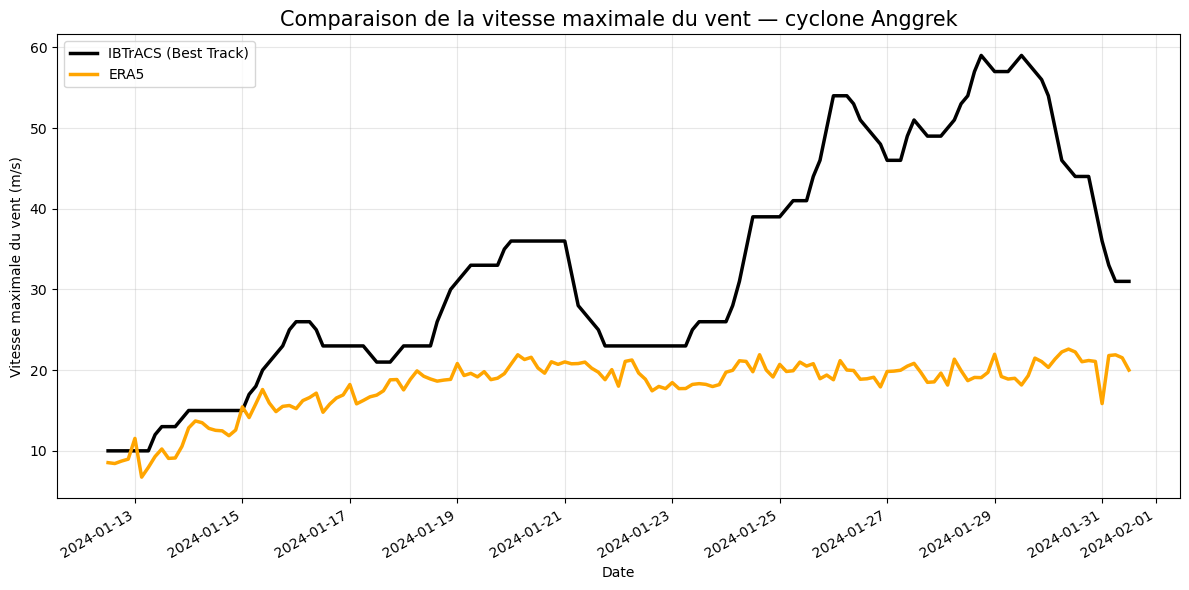

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def tracer_comparaison_vmax(
    fichier_csv: str,
    cyclone: str = "ANGGREK",
    fichier_sortie: str = "comparaison_vmax_anggrek.png",
) -> None:
    """
    Trace l'évolution de Vmax issue d'IBTrACS et d'ERA5 pour un cyclone.

    Paramètres
    ----------
    fichier_csv :
        Chemin vers le fichier CSV.
    cyclone :
        Nom du cyclone à sélectionner.
    fichier_sortie :
        Nom du fichier image produit.
    """

    chemin = Path(fichier_csv)

    if not chemin.exists():
        raise FileNotFoundError(f"Fichier introuvable : {chemin}")

    # Lecture du fichier
    df = pd.read_csv(chemin)

    # Vérification des colonnes nécessaires
    colonnes_requises = {"name", "date", "ibtracs_vmax", "era5_vmax"}
    colonnes_manquantes = colonnes_requises.difference(df.columns)

    if colonnes_manquantes:
        raise ValueError(
            f"Colonnes manquantes dans le CSV : {sorted(colonnes_manquantes)}"
        )

    # Conversion de la date
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Conversion des vitesses en valeurs numériques
    df["ibtracs_vmax"] = pd.to_numeric(
        df["ibtracs_vmax"], errors="coerce"
    )
    df["era5_vmax"] = pd.to_numeric(
        df["era5_vmax"], errors="coerce"
    )

    # Sélection du cyclone
    df_cyclone = (
        df[df["name"].str.upper() == cyclone.upper()]
        .sort_values("date")
        .copy()
    )

    if df_cyclone.empty:
        raise ValueError(f"Aucune donnée trouvée pour le cyclone {cyclone}.")

    # Suppression des dates invalides
    df_cyclone = df_cyclone.dropna(subset=["date"])

    # Création de la figure
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        df_cyclone["date"],
        df_cyclone["ibtracs_vmax"],
        linewidth=2.5,
        label="IBTrACS (Best Track)",
        color="black"
    )

    ax.plot(
        df_cyclone["date"],
        df_cyclone["era5_vmax"],
        linewidth=2.5,
        label="ERA5",
        color="orange"
    )

    ax.set_title(
        f"Comparaison de la vitesse maximale du vent — cyclone {cyclone.capitalize()}",
        fontsize=15,
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Vitesse maximale du vent (m/s)")

    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.autofmt_xdate()
    plt.tight_layout()

    plt.savefig(
        fichier_sortie,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
tracer_comparaison_vmax(csv_anggrek_path)

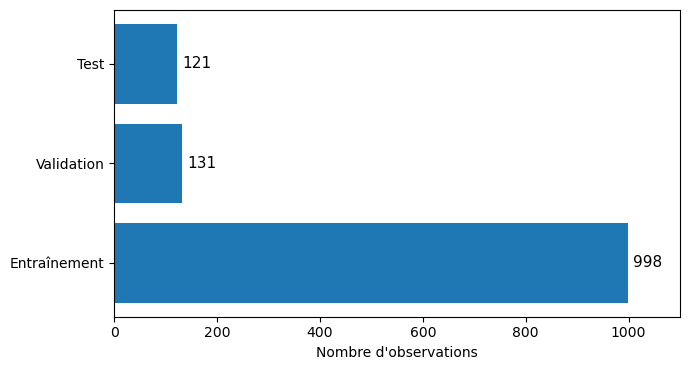

In [2]:
import matplotlib.pyplot as plt

# Données
sets = ["Entraînement", "Validation", "Test"]
counts = [998, 131, 121]

fig, ax = plt.subplots(figsize=(7, 3.8))

bars = ax.barh(sets, counts)

# Valeurs
for bar in bars:
    width = bar.get_width()
    ax.text(width + 10,
            bar.get_y() + bar.get_height()/2,
            f"{int(width)}",
            va='center',
            fontsize=11)

ax.set_xlabel("Nombre d'observations")

ax.set_xlim(0, 1100)

plt.tight_layout()
plt.savefig("split_sets.png", dpi=300)
plt.show()